# Step 1b — DWR / Land IQ crop map check (report only)

Requested by the user on 2026-09-15 before deciding whether to adopt the California DWR
Statewide Crop Mapping (produced by Land IQ) for the analysis units. **Units are not rebuilt here.**

Questions:
1. Strawberry (DWR subclass **T20**) acreage in Monterey and Santa Cruz for 2022 and 2023, by
   "main crop" and "any crop slot", next to CDL 2023 and the California Strawberry Commission's
   12,728-acre projection for the Watsonville/Salinas district.
2. Do the 2023 attributes show whether a field had strawberries in the ground in March 2023?
3. Where do CDL 2023 (class 221) and DWR 2023 (T20) agree and disagree spatially?

Data: `data/raw/dwr_crop_mapping/` (provenance in `SOURCE.md`), read directly from the zip files,
never modified. CDL 2023 `cropland` on its native 30 m grid (EPSG:5070) from Earth Engine,
cached as `data/derived/01b_cdl2023_cropland_30m.tif` (not committed).

Definitions quoted or summarised from the DWR metadata inside the geodatabases:
- Each dataset covers a water year (WY): WY2023 = 1 Oct 2022 – 30 Sep 2023.
- `ADOY1`–`ADOY4`: "Adjusted Day Of Year" of the **peak NDVI** date for crops 1–4. Negative values are
  dates in the previous calendar year (−92 = 1 Oct 2022, −1 = 31 Dec 2022); positive values are in
  the current one (1 = 1 Jan 2023, 273 = 30 Sep 2023). There is **no planting-date field**;
  `YR_PLANTED` is for orchards and groves.
- `MAIN_CROP`: the main season crop for the WY; `MAIN_CROP_DATE`: its peak-NDVI date.
- `MULTIUSE`: S/D/T/Q = single/double/triple/quadruple cropped. Single-crop fields carry their crop in
  slot 2. `COUNTY` is the county of the field centroid.
- `ACRES`: polygon land area; per DWR "not necessarily equal to the summation of crop acres if
  multiple crops were planted through the year".

In [1]:
import warnings

import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyogrio
import rasterio
from rasterio.features import rasterize
from rasterio.windows import from_bounds

import common as C
from cdl import cdl_tif
from maps import add_north_arrow, add_scale_bar

warnings.filterwarnings("ignore", message=".*Measured.*")
pd.set_option("display.width", 200)
ee.Initialize(project=C.EE_PROJECT)

DWR = C.RAW / "dwr_crop_mapping"
FILES = {2022: ("i15_crop_mapping_2022.gdb.zip", "i15_Crop_Mapping_2022"),
         2023: ("i15_crop_mapping_2023_final.gdb.zip", "i15_Crop_Mapping_2023")}
COUNTY_NAMES = ["Monterey", "Santa Cruz"]
T20 = "T20"
SLOTS = [f"CROPTYP{i}" for i in range(1, 5)]
ADOYS = [f"ADOY{i}" for i in range(1, 5)]
ACRE_M2 = 4046.8564224
# California Strawberry Commission projection, Watsonville/Salinas district (supplied by the user;
# see SPEC_CHANGELOG 2026-09-15). The district also includes some Santa Clara and San Benito acreage.
COMMISSION_ACRES = 12728
N_UNITS = len(pd.read_csv(C.DERIVED / "01_units_y2023_centroids.csv"))
DWR_IDS = ", ".join(zf for zf, _ in FILES.values())


def stamp(window):
    print(f"n units (Step 1, provisional 2023 rule) = {N_UNITS} | date window: {window} | "
          f"datasets: DWR Statewide Crop Mapping ({DWR_IDS}); {C.CDL} class {C.CDL_STRAWBERRY}")


print((DWR / "SOURCE.md").read_text(encoding="utf-8"))

# DWR / Land IQ Statewide Crop Mapping — provenance

Publisher: California Department of Water Resources; produced by Land IQ LLC.
Dataset page: https://data.cnra.ca.gov/dataset/statewide-crop-mapping
Files are stored exactly as downloaded and must not be modified (CLAUDE.md §11).

| Year | Resource | Resource page | Download URL | File | Bytes | SHA-256 | CNRA last modified | Downloaded (UTC) |
|---|---|---|---|---|---|---|---|---|
| 2022 | 2022 Statewide Crop Mapping Geodatabase | https://data.cnra.ca.gov/dataset/statewide-crop-mapping/resource/e41f74d2-7ff9-4871-bc95-1e9673fc53cb | https://data.cnra.ca.gov/dataset/6c3d65e3-35bb-49e1-a51e-49d5a2cf09a9/resource/e41f74d2-7ff9-4871-bc95-1e9673fc53cb/download/i15_crop_mapping_2022.gdb.zip | i15_crop_mapping_2022.gdb.zip | 98690638 | 014768c28252c9d3414f07f7a700fbac7569f8e0592f93c8e028ee2f0f2b320c | None | 2026-09-15 |
| 2023 | 2023 Statewide Crop Mapping Geodatabase | https://data.cnra.ca.gov/dataset/statewide-crop-mapping/resource/4e17c

## Load DWR fields in the two counties

In [2]:
cols = ["COUNTY", "MULTIUSE", "ACRES", "MAIN_CROP", "MAIN_CROP_DATE"] + SLOTS + ADOYS
where = "COUNTY IN ('Monterey', 'Santa Cruz')"
dwr = {}
for yr, (zf, lyr) in FILES.items():
    g = pyogrio.read_dataframe(DWR / zf, layer=lyr, where=where, columns=cols)
    g = g.set_geometry(g.geometry.force_2d()).to_crs(C.GRID_CRS)
    g["t20_any"] = g[SLOTS].eq(T20).any(axis=1)
    g["t20_main"] = g.MAIN_CROP.eq(T20)
    g["geom_acres"] = g.area / ACRE_M2
    dwr[yr] = g
    print(f"WY{yr}: {len(g):,} fields | T20 in any slot: {int(g.t20_any.sum()):,} | "
          f"T20 main crop: {int(g.t20_main.sum()):,} | file: {zf}")

C:\Users\austi\CROPCZYK\strawberry-index-insurance\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


WY2022: 18,248 fields | T20 in any slot: 2,066 | T20 main crop: 1,466 | file: i15_crop_mapping_2022.gdb.zip


WY2023: 18,668 fields | T20 in any slot: 1,935 | T20 main crop: 1,551 | file: i15_crop_mapping_2023_final.gdb.zip


## CDL 2023 on its native grid, and county masks

In [3]:
counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
counties = gpd.GeoDataFrame.from_features(counties_fc.getInfo()["features"], crs="EPSG:4326")
counties = counties[["GEOID", "NAME", "geometry"]].sort_values("GEOID").reset_index(drop=True)
bbox = tuple(float(v) for v in np.round(counties.total_bounds + np.array([-0.02, -0.02, 0.02, 0.02]), 3))

CDL_TIF = cdl_tif(C.DERIVED / "01b_cdl2023_cropland_30m.tif", 2023, bbox)
with rasterio.open(CDL_TIF) as src:
    cdl, transform, raster_crs = src.read(1), src.transform, src.crs
shape = cdl.shape
county_id = rasterize([(geom, i + 1) for i, geom in enumerate(counties.to_crs(raster_crs).geometry)],
                      out_shape=shape, transform=transform, fill=0, dtype="uint8")
COUNTY_ID = {n: i + 1 for i, n in enumerate(counties.NAME)}
cdl_straw = cdl == C.CDL_STRAWBERRY
cdl_px = {n: int((cdl_straw & (county_id == i)).sum()) for n, i in COUNTY_ID.items()}
cdl_acres = {n: px * 900 / ACRE_M2 for n, px in cdl_px.items()}
print("CDL 2023 class 221 pixels:", cdl_px, "| total", sum(cdl_px.values()), "(Earth Engine count in Step 1: 51,124)")

first = ee.ImageCollection(C.CDL).filterDate("2023-01-01", "2024-01-01").first()
CDL_NAMES = dict(zip([int(v) for v in first.get("cropland_class_values").getInfo().split(",")],
                     first.get("cropland_class_names").getInfo().split(",")))

CDL 2023 class 221 pixels: {'Monterey': 41573, 'Santa Cruz': 9551} | total 51124 (Earth Engine count in Step 1: 51,124)


## 1. T20 acreage vs CDL 2023 and the Commission projection

In [4]:
out = {}
for yr, g in dwr.items():
    for rule, col in [("main crop = T20", "t20_main"), ("T20 in any slot", "t20_any")]:
        s = g[g[col]]
        by = s.groupby("COUNTY").ACRES.sum().reindex(COUNTY_NAMES, fill_value=0)
        out[(f"DWR WY{yr}", rule)] = {**by.to_dict(), "Both counties": by.sum(), "fields": len(s),
                                     "polygon-area acres (check)": s.geom_acres.sum()}
out[("CDL 2023", "class 221, 30 m pixels")] = {**cdl_acres, "Both counties": sum(cdl_acres.values()),
                                              "fields": np.nan, "polygon-area acres (check)": np.nan}
acre = pd.DataFrame(out).T
acre["% of Commission 12,728 ac"] = 100 * acre["Both counties"] / COMMISSION_ACRES
acre["ratio to CDL 2023"] = acre["Both counties"] / sum(cdl_acres.values())
fmt = acre.copy()
for c in ["Monterey", "Santa Cruz", "Both counties", "polygon-area acres (check)"]:
    fmt[c] = fmt[c].map(lambda v: "" if pd.isna(v) else f"{v:,.0f}")
fmt["fields"] = fmt["fields"].map(lambda v: "" if pd.isna(v) else f"{v:,.0f}")
fmt["% of Commission 12,728 ac"] = fmt["% of Commission 12,728 ac"].map("{:.0f}%".format)
fmt["ratio to CDL 2023"] = fmt["ratio to CDL 2023"].map("{:.2f}".format)
print(fmt.to_string())
print("\nDWR acres use the ACRES field (polygon land area, county by field centroid); CDL acres are 30 m "
      "pixels inside TIGER county polygons. The Commission figure covers the Watsonville/Salinas district, "
      "which includes some Santa Clara and San Benito acreage.")

ACRE_CSV = C.DERIVED / "01b_dwr_acreage.csv"
if ACRE_CSV.exists():
    print(f"{ACRE_CSV.name} exists; not overwritten")
else:
    acre.to_csv(ACRE_CSV)
    print(f"Wrote {ACRE_CSV.name}")
stamp("DWR WY2022 and WY2023; CDL crop year 2023")

                                  Monterey Santa Cruz Both counties fields polygon-area acres (check) % of Commission 12,728 ac ratio to CDL 2023
DWR WY2022 main crop = T20          13,161      2,326        15,487  1,466                     15,487                      122%              1.36
           T20 in any slot          21,416      3,374        24,790  2,066                     24,790                      195%              2.18
DWR WY2023 main crop = T20          14,205      2,605        16,810  1,551                     16,810                      132%              1.48
           T20 in any slot          18,496      3,723        22,219  1,935                     22,219                      175%              1.95
CDL 2023   class 221, 30 m pixels    9,246      2,124        11,370                                                         89%              1.00

DWR acres use the ACRES field (polygon land area, county by field centroid); CDL acres are 30 m pixels inside TIGER county 

## 2. Timing: can the 2023 attributes say a field had strawberries in the ground in March 2023?

There is no planting date. What exists per crop slot is the **peak-NDVI date** (`ADOY`) and the
**order of crops within WY2023**. Fields are grouped by where T20 sits in that sequence.

In [5]:
def adoy_to_date(v):
    if pd.isna(v):
        return pd.NaT
    jan1 = pd.Timestamp("2023-01-01")
    return jan1 + pd.Timedelta(days=int(v) - 1) if v > 0 else jan1 + pd.Timedelta(days=int(v))


g = dwr[2023]
t = g[g.t20_any].copy()
filled = t[SLOTS].apply(lambda col: col.astype(str).str.strip("*").ne("") & col.notna())
t["t20_slot"] = t[SLOTS].eq(T20).to_numpy().argmax(axis=1) + 1
t["n_crops"] = filled.sum(axis=1)
t["first_slot"] = filled.to_numpy().argmax(axis=1) + 1
t["t20_peak"] = [adoy_to_date(r[f"ADOY{k}"]) for k, (_, r) in zip(t.t20_slot, t.iterrows())]
t["pattern"] = np.select(
    [t.n_crops == 1, t.t20_slot == t.first_slot, t.t20_slot > t.first_slot],
    ["A. only crop in WY2023", "B. first crop, then another crop", "C. planted after another crop"],
    default="other")


def next_crop(r):
    later = [r[f"CROPTYP{j}"] for j in range(r.t20_slot + 1, 5) if filled.loc[r.name, f"CROPTYP{j}"]]
    return later[0] if later else "(none)"


t["next_crop"] = t.apply(next_crop, axis=1)
months = pd.period_range("2022-10", "2023-09", freq="M").strftime("%Y-%m").tolist()
t["peak_month"] = t.t20_peak.dt.strftime("%Y-%m").fillna("no peak date")

timing = t.groupby("pattern").agg(fields=("ACRES", "size"), acres=("ACRES", "sum"),
                                  peak_date_known=("t20_peak", lambda s: int(s.notna().sum())),
                                  main_crop_T20=("t20_main", "sum"))
print(timing.round(0).to_string())
print("\nAcres by month of the T20 peak NDVI:")
pm = pd.crosstab(t.pattern, t.peak_month, values=t.ACRES, aggfunc="sum").fillna(0).round(0)
print(pm.reindex(columns=[m for m in months + ["no peak date"] if m in pm.columns]).to_string())
b = t[t.pattern.str.startswith("B")]
print("\nPattern B: crop that follows T20 (fields):", b.next_crop.value_counts().head(6).to_dict())
print("Pattern B: MAIN_CROP (fields):", b.MAIN_CROP.value_counts().head(6).to_dict())

TIMING_CSV = C.DERIVED / "01b_dwr_t20_timing.csv"
if TIMING_CSV.exists():
    print(f"{TIMING_CSV.name} exists; not overwritten")
else:
    pd.concat([timing, pm], axis=1).to_csv(TIMING_CSV)
    print(f"Wrote {TIMING_CSV.name}")
stamp("DWR WY2023 (1 Oct 2022 – 30 Sep 2023)")

                                  fields    acres  peak_date_known  main_crop_T20
pattern                                                                          
A. only crop in WY2023              1320  14683.0                0           1320
B. first crop, then another crop     611   7489.0              611            227
C. planted after another crop          4     47.0                4              4

Acres by month of the T20 peak NDVI:
peak_month                        2022-10  2022-11  2022-12  2023-01  2023-02  2023-03  2023-07  2023-08  2023-09  no peak date
pattern                                                                                                                        
A. only crop in WY2023                0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0       14683.0
B. first crop, then another crop   4164.0   1986.0    529.0    613.0    136.0     60.0      0.0      0.0      0.0           0.0
C. planted after another crop         0.

## 3. Spatial agreement: CDL 2023 class 221 vs DWR WY2023 T20

DWR polygons are burned onto CDL's 30 m grid (pixel centre inside polygon). "Near a DWR T20 field"
means outside the polygon but within 1 pixel (30 m) or 3 pixels (90 m) of it. "Edge" DWR pixels are
those within 1 pixel of the polygon boundary.

In [6]:
g23 = dwr[2023].to_crs(raster_crs)


def burn(geoms, values=None, dtype="uint8"):
    shapes = ((geom, 1) for geom in geoms) if values is None else zip(geoms, values)
    return rasterize(shapes, out_shape=shape, transform=transform, fill=0, dtype=dtype)


def dilate(m, k):
    out = m.copy()
    for _ in range(k):
        p = np.pad(out, 1)
        out = (p[1:-1, 1:-1] | p[:-2, 1:-1] | p[2:, 1:-1] | p[1:-1, :-2] | p[1:-1, 2:]
               | p[:-2, :-2] | p[:-2, 2:] | p[2:, :-2] | p[2:, 2:])
    return out


dwr_mask = {"main crop = T20": burn(g23[g23.t20_main].geometry).astype(bool),
            "T20 in any slot": burn(g23[g23.t20_any].geometry).astype(bool)}
codes = sorted(g23.MAIN_CROP.fillna("none").unique())
code_id = {c: i + 1 for i, c in enumerate(codes)}
id_code = {0: "no DWR field polygon", **{i: c for c, i in code_id.items()}}
dwr_main_crop = burn(g23.geometry, [code_id[c] for c in g23.MAIN_CROP.fillna("none")], dtype="uint16")

rows = []
for rule, dm in dwr_mask.items():
    near1, near3 = dilate(dm, 1), dilate(dm, 3)
    edge = dm & ~(~dilate(~dm, 1))
    for county in COUNTY_NAMES + ["Both counties"]:
        cm = county_id > 0 if county == "Both counties" else county_id == COUNTY_ID[county]
        c, d = cdl_straw & cm, dm & cm
        both, c_out, d_miss = c & d, c & ~d, d & ~cdl_straw
        rows.append({
            "DWR rule": rule, "county": county,
            "CDL strawberry px": int(c.sum()), "DWR T20 px": int(d.sum()),
            "% of CDL strawberry inside DWR T20": 100 * both.sum() / c.sum(),
            "% within 30 m of DWR T20 (outside)": 100 * (c_out & near1).sum() / c.sum(),
            "% 30-90 m away": 100 * (c_out & near3 & ~near1).sum() / c.sum(),
            "% > 90 m from any DWR T20": 100 * (c_out & ~near3).sum() / c.sum(),
            "% of DWR T20 labelled strawberry by CDL": 100 * both.sum() / d.sum(),
            "% of DWR T20 missed by CDL that is edge px": 100 * (d_miss & cm & edge).sum() / max(1, (d_miss & cm).sum()),
        })
overlap = pd.DataFrame(rows).set_index(["DWR rule", "county"])
print(overlap.round(1).to_string())

in_cty = county_id > 0
far = cdl_straw & in_cty & ~dilate(dwr_mask["T20 in any slot"], 3)
v = pd.Series(dwr_main_crop[far]).map(id_code).value_counts()
print(f"\nCDL strawberry px > 90 m from any DWR T20 field ({int(far.sum())} px): DWR main crop there")
print((100 * v / v.sum()).round(1).head(8).to_string())
missed = dwr_mask["main crop = T20"] & in_cty & ~cdl_straw
v = pd.Series(cdl[missed]).map(CDL_NAMES).value_counts()
print(f"\nDWR main-crop T20 px not labelled strawberry by CDL ({int(missed.sum())} px): CDL class there")
print((100 * v / v.sum()).round(1).head(8).to_string())

OVERLAP_CSV = C.DERIVED / "01b_dwr_cdl_overlap.csv"
if OVERLAP_CSV.exists():
    print(f"{OVERLAP_CSV.name} exists; not overwritten")
else:
    overlap.to_csv(OVERLAP_CSV)
    print(f"Wrote {OVERLAP_CSV.name}")
stamp("DWR WY2023; CDL crop year 2023")

                               CDL strawberry px  DWR T20 px  % of CDL strawberry inside DWR T20  % within 30 m of DWR T20 (outside)  % 30-90 m away  % > 90 m from any DWR T20  % of DWR T20 labelled strawberry by CDL  % of DWR T20 missed by CDL that is edge px
DWR rule        county                                                                                                                                                                                                                                              
main crop = T20 Monterey                   41573       63742                                31.4                                 3.8             7.7                       57.1                                     20.5                                        49.6
                Santa Cruz                  9551       11883                                37.5                                 7.0            10.8                       44.7                                     30.1 


CDL strawberry px > 90 m from any DWR T20 field (24650 px): DWR main crop there
T4                      37.4
T30                     34.2
no DWR field polygon    10.2
T18                      7.7
T19                      3.4
X                        2.6
G6                       2.2
T16                      0.4

DWR main-crop T20 px not labelled strawberry by CDL (58978 px): CDL class there
Grass/Pasture            37.8
Alfalfa                   6.4
Herbaceous Wetlands       6.4
Fallow/Idle Cropland      5.9
Shrubland                 5.9
Grapes                    3.3
Woody Wetlands            2.8
Other Hay/Non Alfalfa     2.4
01b_dwr_cdl_overlap.csv exists; not overwritten
n units (Step 1, provisional 2023 rule) = 127 | date window: DWR WY2023; CDL crop year 2023 | datasets: DWR Statewide Crop Mapping (i15_crop_mapping_2022.gdb.zip, i15_crop_mapping_2023_final.gdb.zip); USDA/NASS/CDL class 221


## 4. Step 1 units vs DWR fields

Share of each 250 m unit (provisional 2023 rule) covered by DWR WY2023 T20 polygons, and the DWR
main crop covering the largest share of the unit. The both-years sensitivity set is a subset.

In [7]:
units = gpd.read_file(C.DERIVED / "01_units_y2023_polygons.geojson").to_crs(C.GRID_CRS)
both_ids = set(pd.read_csv(C.DERIVED / "01_units_both_centroids.csv").unit_id)
g = dwr[2023]
near = g[g.intersects(units.union_all())]
for rule, col in [("main", "t20_main"), ("any", "t20_any")]:
    units[f"dwr_t20_{rule}_frac"] = units.intersection(near[near[col]].union_all()).area / units.area
pieces = gpd.overlay(units[["unit_id", "geometry"]], near[["MAIN_CROP", "geometry"]], how="intersection")
pieces["a"] = pieces.area
dominant = pieces.sort_values("a").groupby("unit_id").MAIN_CROP.last()
units["dwr_dominant_main_crop"] = units.unit_id.map(dominant).fillna("no DWR field")
units["both_years"] = units.unit_id.isin(both_ids)

rows = []
for label, u in [("2023 rule (n = %d)" % len(units), units),
                 ("both-years set (n = %d)" % units.both_years.sum(), units[units.both_years])]:
    f = u.dwr_t20_main_frac
    rows.append({"unit set": label,
                 "median % covered by DWR main-crop T20": 100 * f.median(),
                 "units ≥ 50% covered": int((f >= 0.5).sum()),
                 "units < 5% covered": int((f < 0.05).sum()),
                 "median % covered, T20 any slot": 100 * u.dwr_t20_any_frac.median()})
print(pd.DataFrame(rows).set_index("unit set").round(1).to_string())
print("\nDWR main crop covering the largest share of each unit (2023 rule, units):")
print(units.dwr_dominant_main_crop.value_counts().head(8).to_string())
print("\nsame, both-years set:")
print(units[units.both_years].dwr_dominant_main_crop.value_counts().head(8).to_string())

UNITS_CSV = C.DERIVED / "01b_units_dwr_cover.csv"
if UNITS_CSV.exists():
    print(f"{UNITS_CSV.name} exists; not overwritten")
else:
    units.drop(columns="geometry").to_csv(UNITS_CSV, index=False)
    print(f"Wrote {UNITS_CSV.name}")
stamp("DWR WY2023; CDL crop year 2023")

                         median % covered by DWR main-crop T20  units ≥ 50% covered  units < 5% covered  median % covered, T20 any slot
unit set                                                                                                                               
2023 rule (n = 127)                                       33.3                   59                  51                            70.3
both-years set (n = 15)                                   44.3                    7                   7                            74.9



DWR main crop covering the largest share of each unit (2023 rule, units):
dwr_dominant_main_crop
T20    63
T4     41
T30    14
G6      4
T18     3
X       2

same, both-years set:
dwr_dominant_main_crop
T20    7
T4     6
T30    2
01b_units_dwr_cover.csv exists; not overwritten
n units (Step 1, provisional 2023 rule) = 127 | date window: DWR WY2023; CDL crop year 2023 | datasets: DWR Statewide Crop Mapping (i15_crop_mapping_2022.gdb.zip, i15_crop_mapping_2023_final.gdb.zip); USDA/NASS/CDL class 221


## Close-up map: lower Pajaro Valley

Drawn in EPSG:3310 so north is up (in EPSG:5070 grid north is rotated about 15° here). CDL pixels
are reprojected by nearest neighbour for display only; the statistics above use CDL's native grid.

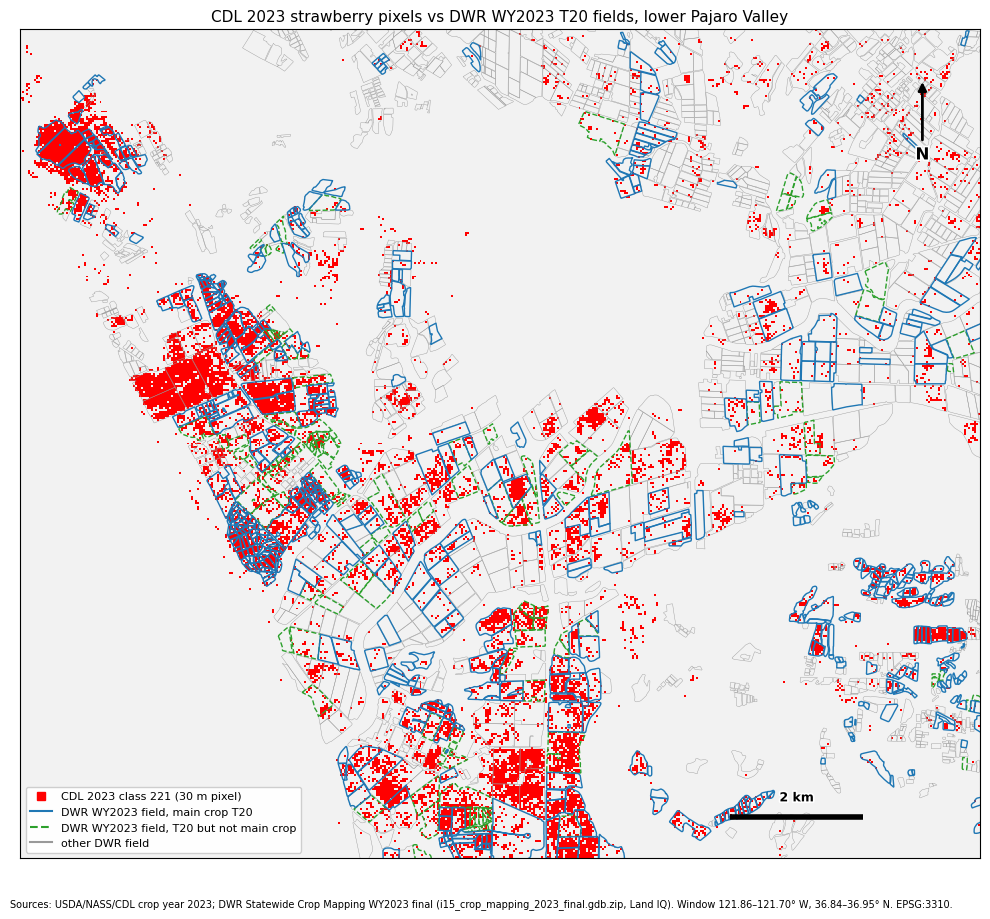

Saved supp_dwr_vs_cdl_pajaro.png
n units (Step 1, provisional 2023 rule) = 127 | date window: DWR WY2023; CDL crop year 2023 | datasets: DWR Statewide Crop Mapping (i15_crop_mapping_2022.gdb.zip, i15_crop_mapping_2023_final.gdb.zip); USDA/NASS/CDL class 221


In [8]:
from matplotlib.colors import ListedColormap
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject
from shapely.geometry import box

VIEW_LL = (-121.86, 36.84, -121.70, 36.95)
x0, y0, x1, y1 = gpd.GeoSeries([box(*VIEW_LL)], crs="EPSG:4326").to_crs(C.GRID_CRS).total_bounds
res = 30
disp = np.zeros((int(np.ceil((y1 - y0) / res)), int(np.ceil((x1 - x0) / res))), dtype="uint8")
reproject(cdl_straw.astype("uint8"), disp, src_transform=transform, src_crs=raster_crs,
          dst_transform=from_origin(x0, y1, res, res), dst_crs=C.GRID_CRS, resampling=Resampling.nearest)
ext = (x0, x0 + res * disp.shape[1], y1 - res * disp.shape[0], y1)
clip = dwr[2023].cx[x0:x1, y0:y1]

fig, ax = plt.subplots(figsize=(10, 10 * (ext[3] - ext[2]) / (ext[1] - ext[0]) + 0.8))
fig.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.04)
ax.set_facecolor("#f2f2f2")
ax.imshow(np.ma.masked_equal(disp, 0), extent=ext, cmap=ListedColormap(["red"]), interpolation="nearest")
clip[~clip.t20_any].boundary.plot(ax=ax, color="0.6", lw=0.3)
clip[clip.t20_any & ~clip.t20_main].boundary.plot(ax=ax, color="tab:green", lw=1.0, ls="--")
clip[clip.t20_main].boundary.plot(ax=ax, color="tab:blue", lw=1.0)
ax.set_xlim(ext[0], ext[1])
ax.set_ylim(ext[2], ext[3])
ax.set_xticks([])
ax.set_yticks([])
ax.plot([], [], "s", color="red", label="CDL 2023 class 221 (30 m pixel)")
ax.plot([], [], color="tab:blue", label="DWR WY2023 field, main crop T20")
ax.plot([], [], color="tab:green", ls="--", label="DWR WY2023 field, T20 but not main crop")
ax.plot([], [], color="0.6", label="other DWR field")
ax.legend(loc="lower left", fontsize=8, framealpha=0.95)
add_scale_bar(ax, 2, loc=(0.74, 0.05), color="black")
add_north_arrow(ax, color="black")
ax.set_title("CDL 2023 strawberry pixels vs DWR WY2023 T20 fields, lower Pajaro Valley", fontsize=11)
fig.text(0.01, 0.005, f"Sources: {C.CDL} crop year 2023; DWR Statewide Crop Mapping WY2023 final "
         "(i15_crop_mapping_2023_final.gdb.zip, Land IQ). Window 121.86–121.70° W, 36.84–36.95° N. EPSG:3310.",
         fontsize=7)
SUPP = C.FIGURES / "supp_dwr_vs_cdl_pajaro.png"
fig.savefig(SUPP, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {SUPP.name}")
stamp("DWR WY2023; CDL crop year 2023")